# 10 — Revised synthetic benchmark with the standard SSVI–Dupire baseline

A literature check shows that the standard practical local-volatility workflow is usually a **two-step procedure**:

1. fit a smooth implied-volatility or total-variance surface;
2. apply the Dupire formula to that smooth surface.

SVI is a widely used implied-volatility parameterisation. We use its surface form, **SSVI**, because it gives a smooth total-variance surface and allows explicit no-arbitrage diagnostics.

The benchmark now compares:

1. constant 20% reference;
2. raw direct Dupire;
3. spline-smoothed direct Dupire;
4. SSVI-smoothed implied variance followed by Dupire;
5. our operator/Schrödinger-regularised inverse method.

All primary RMSE values use exactly the same evaluation points.

In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

project_root = Path.cwd().resolve()
if not (project_root / "src").exists():
    if (project_root.parent / "src").exists():
        project_root = project_root.parent
    else:
        raise FileNotFoundError(
            "Could not find the project root. Start Jupyter from the "
            "dupire_local_vol_project folder."
        )

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

print("Project root:", project_root)

Project root: /mnt/data/dupire_audit/dupire_local_vol_project


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.evaluation.benchmark import (
    compare_methods_on_quote_grid,
    repeated_noise_benchmark,
)
from src.inverse.linearized_inverse import (
    price_quotes_from_log_variance,
)
from src.regularization.potentials import (
    combine_potentials,
    confidence_potential,
    quote_confidence_surface,
    wing_potential,
)
from src.regularization.scaling import (
    build_nondimensional_regularization_matrix,
)

## 1. Load the synthetic truth and final operator-regularised MAP

The final Stage 9 surface is the nonlinear operator-regularised MAP estimate.

The SSVI baseline is fitted directly to the same noisy option prices.

In [3]:
quote_path = (
    project_root
    / "data"
    / "synthetic"
    / "smile_quotes.csv"
)
stage_08_path = (
    project_root
    / "outputs"
    / "stage_08"
    / "selected_scaled_calibration.npz"
)
stage_09_path = (
    project_root
    / "outputs"
    / "stage_09"
    / "laplace_posterior.npz"
)

for required_path in [
    quote_path,
    stage_08_path,
    stage_09_path,
]:
    if not required_path.exists():
        raise FileNotFoundError(
            f"Required previous-stage output is missing: {required_path}"
        )

quotes = pd.read_csv(quote_path)
stage_08 = np.load(stage_08_path)
stage_09 = np.load(stage_09_path)

calibration_T = stage_09["calibration_maturities"]
calibration_x = stage_09["calibration_x"]
map_volatility = stage_09["map_volatility"]

print("Number of quotes:", len(quotes))
print("MAP surface shape:", map_volatility.shape)

Number of quotes: 78
MAP surface shape: (5, 9)


## 2. Fit SSVI and compare every method on one shared mask

SSVI is fitted to implied total variance

$$
w(k,T)=\sigma_{\mathrm{BS}}(k,T)^2T.
$$

The SSVI form is

$$
w(k,\theta)
=
\frac{\theta}{2}
\left[
1+\rho\varphi(\theta)k
+
\sqrt{(\varphi(\theta)k+\rho)^2+1-\rho^2}
\right].
$$

After fitting, the standard implied-variance form of Dupire is applied analytically.

In [4]:
comparison_table, pointwise_results, metadata = (
    compare_methods_on_quote_grid(
        quote_data=quotes,
        regularized_maturities=calibration_T,
        regularized_log_moneyness=calibration_x,
        regularized_volatility_surface=map_volatility,
        spot=100.0,
        reference_volatility=0.20,
    )
)

ssvi_fit = metadata["ssvi_fit"]

print("SSVI fit success:", ssvi_fit.success)
print("Usable implied-volatility quotes:", ssvi_fit.number_of_usable_quotes)
print("SSVI rho:", ssvi_fit.rho)
print("SSVI eta:", ssvi_fit.eta)
print("SSVI gamma:", ssvi_fit.gamma)
print("SSVI fit time (seconds):", ssvi_fit.fit_seconds)

comparison_table

SSVI fit success: True
Usable implied-volatility quotes: 74
SSVI rho: -0.009162460616214329
SSVI eta: 0.5255673090864637
SSVI gamma: 0.2608371125682779
SSVI fit time (seconds): 0.5817839530000128


,number_of_evaluation_points,rmse,mae,maximum_absolute_error,bias,method,method_valid_fraction
0,72,0.001898,0.001414,0.006749,0.001166,ssvi_dupire,1.000000
1,72,0.006364,0.005298,0.014081,0.000274,operator_regularized,1.000000
2,72,0.011604,0.008933,0.025425,-0.008933,constant_reference,1.000000
3,72,0.024996,0.015911,0.096878,-0.005811,smoothed_dupire,0.948718
4,72,0.044205,0.025525,0.201384,-0.005798,raw_dupire,0.935897


In [5]:
shared_count = int(
    pointwise_results["shared_valid"].sum()
)

rmse_by_method = comparison_table.set_index(
    "method"
)["rmse"]

print(
    "Shared evaluation points:",
    shared_count,
    "out of",
    len(pointwise_results),
)
print(
    "Operator RMSE:",
    f"{rmse_by_method['operator_regularized']:.6f}",
)
print(
    "SSVI-Dupire RMSE:",
    f"{rmse_by_method['ssvi_dupire']:.6f}",
)
print(
    "SSVI improvement over operator model:",
    f"{rmse_by_method['operator_regularized'] / rmse_by_method['ssvi_dupire']:.2f}x lower RMSE",
)

Shared evaluation points: 72 out of 78
Operator RMSE: 0.006364
SSVI-Dupire RMSE: 0.001898
SSVI improvement over operator model: 3.35x lower RMSE


## 3. Honest interpretation

On this synthetic smile, SSVI–Dupire is the most accurate method.

This is plausible because the true surface is smooth, low-dimensional and close to the class of shapes that SSVI is designed to represent. Our operator method is more flexible, but that flexibility is not automatically beneficial when the truth is well approximated by a compact parametric surface.

Therefore, the defensible claim is now:

> Our method strongly improves on raw and generic spline-smoothed Dupire, but SSVI–Dupire is better on this smooth SSVI-friendly synthetic experiment.

To justify the operator method’s extra flexibility, later experiments should include localised structures, sparse quotes, irregular grids, misspecification and real data.

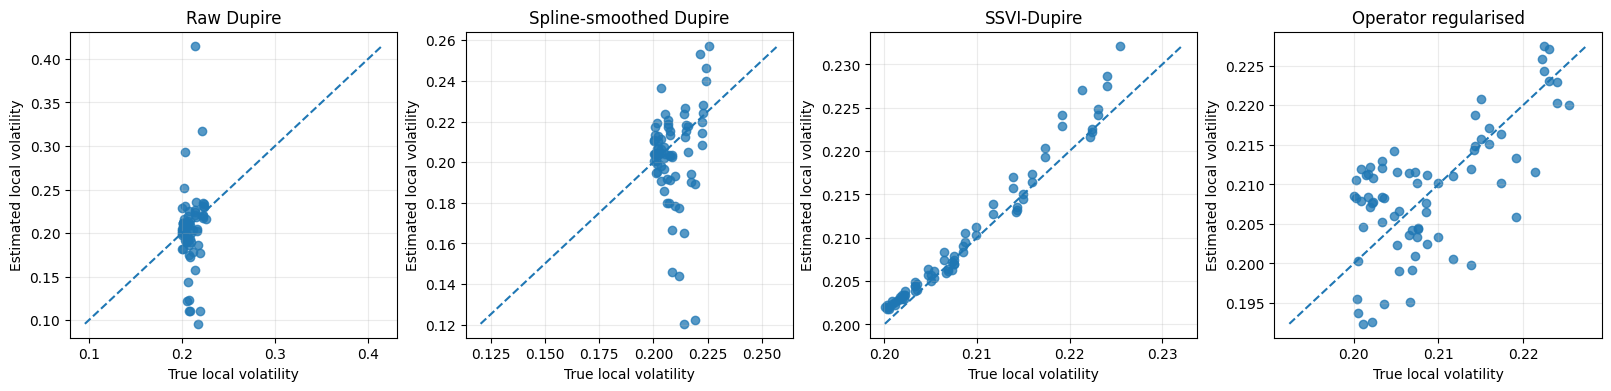

In [6]:
evaluation_points = pointwise_results[
    pointwise_results["shared_valid"]
].copy()

method_titles = [
    ("raw_dupire", "Raw Dupire"),
    ("smoothed_dupire", "Spline-smoothed Dupire"),
    ("ssvi_dupire", "SSVI-Dupire"),
    ("operator_regularized", "Operator regularised"),
]

figure, axes = plt.subplots(
    1,
    4,
    figsize=(16, 3.8),
    constrained_layout=True,
)

for axis, (column, title) in zip(axes, method_titles):
    axis.scatter(
        evaluation_points["true_local_volatility"],
        evaluation_points[column],
        alpha=0.75,
    )
    minimum_value = min(
        evaluation_points["true_local_volatility"].min(),
        evaluation_points[column].min(),
    )
    maximum_value = max(
        evaluation_points["true_local_volatility"].max(),
        evaluation_points[column].max(),
    )
    axis.plot(
        [minimum_value, maximum_value],
        [minimum_value, maximum_value],
        linestyle="--",
    )
    axis.set_title(title)
    axis.set_xlabel("True local volatility")
    axis.set_ylabel("Estimated local volatility")
    axis.grid(alpha=0.25)

plt.show()

## 4. Repeated-noise robustness comparison

We redraw quote noise ten times while keeping the same clean option surface.

The SSVI baseline is refitted for every noise realisation. The operator method uses the same Stage 8 linearised inverse map and selected regularisation settings, which isolates sensitivity to observation noise at moderate computational cost.

In [7]:
reference_log_variance = stage_08[
    "reference_log_variance"
]
reference_jacobian = stage_08["jacobian"]
weights = stage_08["weights"]
selected_lambda = float(stage_08["selected_lambda"])

reference_prices = price_quotes_from_log_variance(
    log_variance_surface=reference_log_variance,
    calibration_maturities=calibration_T,
    calibration_log_moneyness=calibration_x,
    quote_data=quotes,
    spot=100.0,
    number_of_strike_points=151,
    number_of_time_steps=120,
)

wing = wing_potential(
    log_moneyness=calibration_x,
    maturities=calibration_T,
    strength=0.20,
    power=2.0,
    start=0.20,
)
confidence = quote_confidence_surface(
    log_moneyness=calibration_x,
    maturities=calibration_T,
    quote_log_moneyness=quotes[
        "log_moneyness"
    ].to_numpy(),
    quote_maturities=quotes[
        "maturity"
    ].to_numpy(),
    log_moneyness_bandwidth=0.09,
    maturity_bandwidth=0.30,
)
confidence_penalty = confidence_potential(
    confidence,
    strength=0.20,
)
combined_potential = combine_potentials(
    wing,
    confidence_penalty,
)

regularization_matrix, _, _, _ = (
    build_nondimensional_regularization_matrix(
        maturities=calibration_T,
        log_moneyness=calibration_x,
        alpha_x=0.005,
        alpha_T=0.002,
        beta=1e-4,
        potential=combined_potential,
    )
)

noise_results = repeated_noise_benchmark(
    clean_quote_data=quotes,
    random_seeds=range(10),
    reference_prices=reference_prices,
    jacobian=reference_jacobian,
    weights=weights,
    reference_log_variance=reference_log_variance,
    calibration_maturities=calibration_T,
    calibration_log_moneyness=calibration_x,
    regularization_matrix=regularization_matrix,
    regularization_strength=selected_lambda,
    spot=100.0,
)

robustness_summary = (
    noise_results.groupby("method")
    .agg(
        mean_rmse=("rmse", "mean"),
        sd_rmse=("rmse", "std"),
        minimum_rmse=("rmse", "min"),
        maximum_rmse=("rmse", "max"),
        mean_mae=("mae", "mean"),
        mean_shared_valid_fraction=(
            "shared_valid_fraction",
            "mean",
        ),
    )
    .sort_values("mean_rmse")
    .reset_index()
)

robustness_summary

,method,mean_rmse,sd_rmse,minimum_rmse,maximum_rmse,mean_mae,mean_shared_valid_fraction
0,ssvi_dupire,0.001356,0.000317,0.000974,0.001995,0.001047,0.914103
1,operator_regularized_linearized,0.005578,0.000815,0.004409,0.007074,0.004507,0.914103
2,constant_reference,0.011970,0.000273,0.011604,0.012371,0.009172,0.914103
3,smoothed_dupire,0.043176,0.046284,0.016399,0.171778,0.018360,0.914103
4,raw_dupire,0.044357,0.013632,0.032694,0.078440,0.023777,0.914103


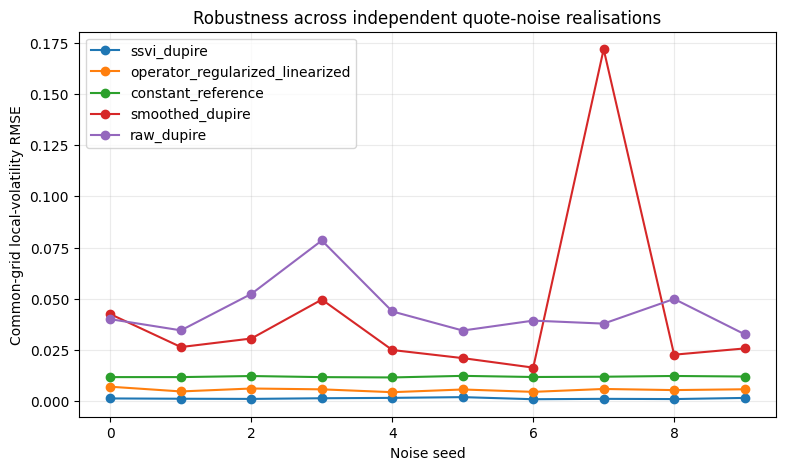

In [8]:
plt.figure(figsize=(9, 5.0))

for method in robustness_summary["method"]:
    method_data = noise_results[
        noise_results["method"] == method
    ]
    plt.plot(
        method_data["seed"],
        method_data["rmse"],
        marker="o",
        label=method,
    )

plt.xlabel("Noise seed")
plt.ylabel("Common-grid local-volatility RMSE")
plt.title("Robustness across independent quote-noise realisations")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

## 5. What this benchmark establishes

The revised comparison is stronger because it includes the standard parametric industry-style baseline rather than only naive numerical differentiation.

The result is nuanced:

- raw Dupire is unstable;
- generic spline smoothing helps but remains sensitive;
- our operator method is much better than both;
- SSVI–Dupire is best for this smooth synthetic smile.

This means the next synthetic benchmark should test a localised bump or another non-SSVI structure. That is where a flexible operator-regularised inverse method has a meaningful opportunity to outperform a restrictive parametric surface.

## 6. References behind the added baseline

- Friz and Gerhold, *Don't stay local — extrapolation analytics for Dupire's local volatility*: describes the typical two-step workflow of smoothing the implied-volatility surface and then applying Dupire.
- Gatheral and Jacquier, *Arbitrage-free SVI volatility surfaces*: describes SVI as widely used and develops arbitrage-free surface constructions.
- Ogetbil and Hientzsch, *Extensions of Dupire Formula*: discusses practice using parametrised or dense implied-total-variance surfaces before evaluating Dupire.

## 7. Save the revised benchmark

In [9]:
output_directory = (
    project_root
    / "outputs"
    / "stage_10"
)
output_directory.mkdir(
    parents=True,
    exist_ok=True,
)

comparison_path = (
    output_directory
    / "common_grid_comparison_with_ssvi.csv"
)
pointwise_path = (
    output_directory
    / "common_grid_pointwise_with_ssvi.csv"
)
noise_path = (
    output_directory
    / "repeated_noise_results_with_ssvi.csv"
)
summary_path = (
    output_directory
    / "repeated_noise_summary_with_ssvi.csv"
)
implied_path = (
    output_directory
    / "ssvi_implied_variance_inputs.csv"
)

comparison_table.to_csv(
    comparison_path,
    index=False,
)
pointwise_results.to_csv(
    pointwise_path,
    index=False,
)
noise_results.to_csv(
    noise_path,
    index=False,
)
robustness_summary.to_csv(
    summary_path,
    index=False,
)
metadata["ssvi_implied_data"].to_csv(
    implied_path,
    index=False,
)

print(comparison_path)
print(pointwise_path)
print(noise_path)
print(summary_path)
print(implied_path)

/mnt/data/dupire_audit/dupire_local_vol_project/outputs/stage_10/common_grid_comparison_with_ssvi.csv
/mnt/data/dupire_audit/dupire_local_vol_project/outputs/stage_10/common_grid_pointwise_with_ssvi.csv
/mnt/data/dupire_audit/dupire_local_vol_project/outputs/stage_10/repeated_noise_results_with_ssvi.csv
/mnt/data/dupire_audit/dupire_local_vol_project/outputs/stage_10/repeated_noise_summary_with_ssvi.csv
/mnt/data/dupire_audit/dupire_local_vol_project/outputs/stage_10/ssvi_implied_variance_inputs.csv


## Revised Stage 10 result

The project now compares the proposed operator-regularised method with the standard SSVI–Dupire workflow.

The benchmark does **not** show that our method is universally superior. Instead, it identifies where each method is strong and defines the next required stress test.